# Exercise 5: BLOB Analysis

In [1]:
from skimage import io, color, morphology
from skimage.util import img_as_float, img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb

In [2]:
def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis('off')
    io.show()

## Exercise 1

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


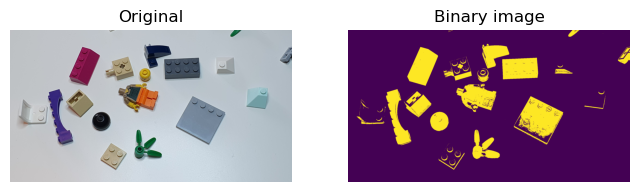

In [3]:
# Directory containing images
in_dir = "data/"

# Lego 5 image
im_name = "lego_4_small.png"

# Read the image
im_org = io.imread(in_dir + im_name)

# Convert to grayscale
im_org_grayscale = color.rgb2gray(im_org)

# OTSU thresholding
thres = threshold_otsu(im_org_grayscale)
bin_img = im_org_grayscale < thres

# Show original vs OTSU
show_comparison(im_org, bin_img, 'Binary image')

## Exercise 2

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


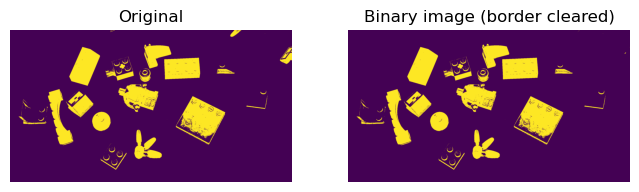

In [4]:
# Remove border BLOBs from the binary image
cleared_border_img = segmentation.clear_border(bin_img)

# Show binary vs border cleared
show_comparison(bin_img, cleared_border_img, 'Binary image (border cleared)')

## Exercise 3

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


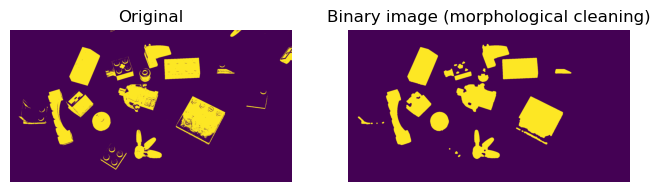

In [5]:
# Cleaning using morphological operations: closing + opening (disk radius 5)
footprint = morphology.disk(5)

closed = morphology.closing(cleared_border_img, footprint)
opened = morphology.opening(closed, footprint)

show_comparison(bin_img, opened, 'Binary image (morphological cleaning)')

# Exercise 4

In [6]:
label_img = measure.label(opened)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")

Number of labels: 29


## Exercise 5

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


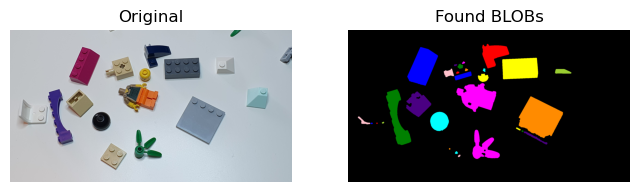

In [7]:
labeled_img = label2rgb(label_img)
show_comparison(im_org, labeled_img, 'Found BLOBs')

# Exercise 6

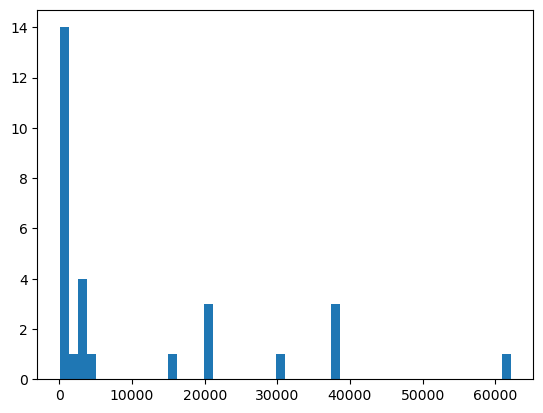

In [8]:
# Area feature
region_props = measure.regionprops(label_img)
areas = np.array([prop.area for prop in region_props])
plt.hist(areas, bins=50)
plt.show()

## Exercise 7

In [9]:
# TODO

## Cell counting

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/1875039094.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gray, vmin=0, vmax=150)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/1875039094.py:8: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


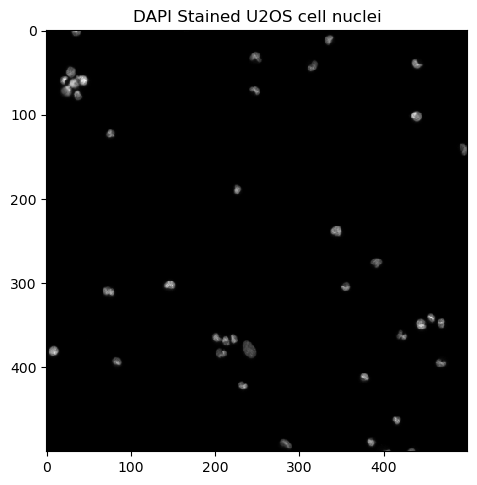

In [10]:
in_dir = "data/"
img_org = io.imread(in_dir + 'Sample E2 - U2OS DAPI channel.tiff')
# slice to extract smaller image
img_small = img_org[700:1200, 900:1400]
img_gray = img_as_ubyte(img_small) 
io.imshow(img_gray, vmin=0, vmax=150)
plt.title('DAPI Stained U2OS cell nuclei')
io.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/158489352.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


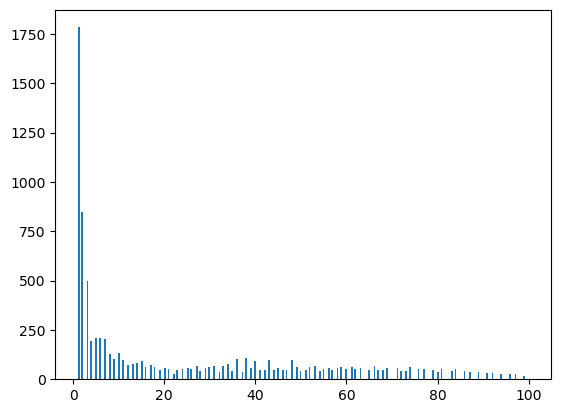

In [11]:
# avoid bin with value 0 due to the very large number of background pixels
plt.hist(img_gray.ravel(), bins=256, range=(1, 100))
io.show()

## Exercise 8

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


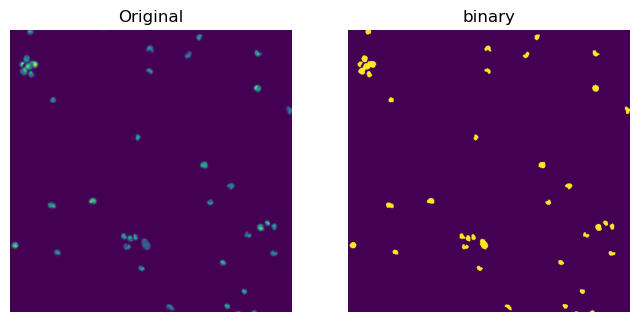

In [12]:
thres = threshold_otsu(img_gray)
img_bin = img_gray > thres
show_comparison(img_gray, img_bin, 'binary')


## Exercise 9

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


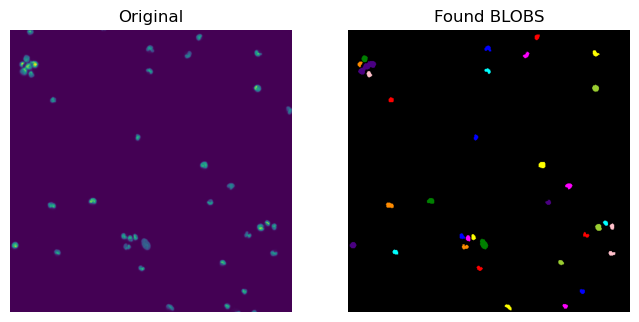

In [13]:
img_c_b = segmentation.clear_border(img_bin)

label_img = measure.label(img_c_b)
image_label_overlay = label2rgb(label_img)
show_comparison(img_gray, image_label_overlay, 'Found BLOBS')

## Exercise 10

In [14]:
# Compute a set of features for each object
region_props = measure.regionprops(label_img)

In [15]:
areas = np.array([prop.area for prop in region_props])

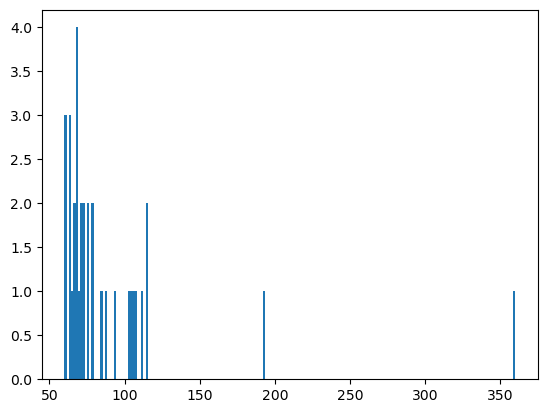

In [16]:
plt.hist(areas, bins=200)
plt.show()

## Exercise 11

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


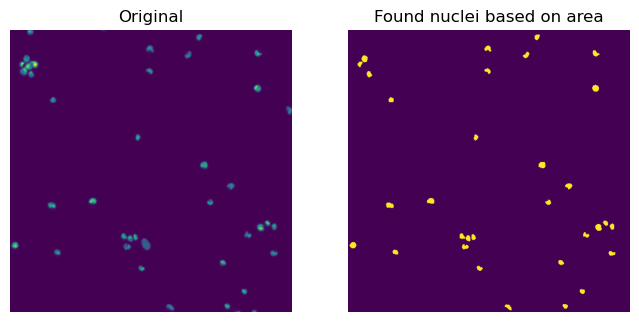

In [17]:
min_area = 50
max_area = 150

# Create a copy of the label_img
label_img_filter = label_img
for region in region_props:
	# Find the areas that do not fit our criteria
	if region.area > max_area or region.area < min_area:
		# set the pixels in the invalid areas to background
		for cords in region.coords:
			label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img_small, i_area, 'Found nuclei based on area')

## Exercise 12

In [18]:
perimeters = np.array([prop.perimeter for prop in region_props])

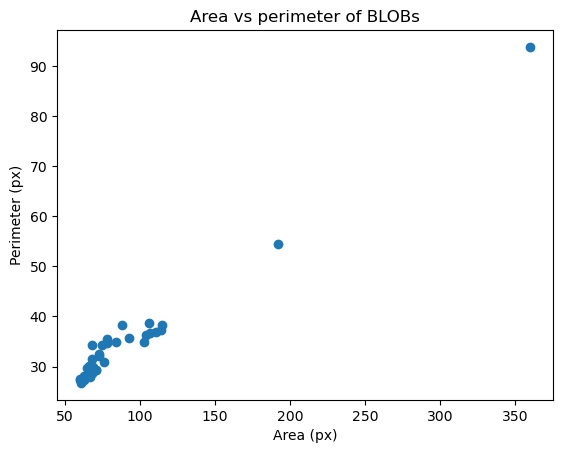

In [19]:
plt.scatter(areas, perimeters)
plt.xlabel('Area (px)')
plt.ylabel('Perimeter (px)')
plt.title('Area vs perimeter of BLOBs')
plt.show()

## Exercise 13

In [20]:
circularities = (4 * np.pi * areas) / (perimeters**2)

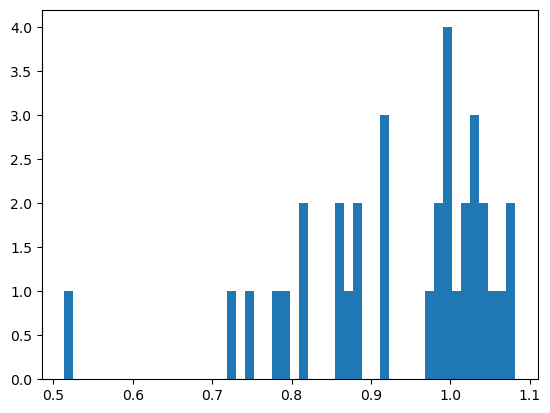

In [21]:
plt.hist(circularities, bins=50)
plt.show()

## Exercise 14

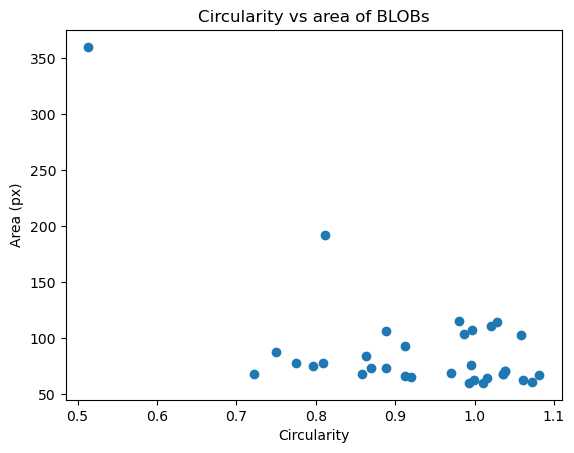

In [22]:
plt.scatter(circularities, areas)
plt.xlabel('Circularity')
plt.ylabel('Area (px)')
plt.title('Circularity vs area of BLOBs')
plt.show()

In [23]:
def cell_counting(img_gray, min_area = 10, max_area = 150, min_circ = 0.7):

    # To binary
    thres = threshold_otsu(img_gray)
    img_bin = img_gray > thres

    # Remove border
    img_c_b = segmentation.clear_border(img_bin)

    # Label objects (BLOBs)
    label_img = measure.label(img_c_b)

    # Extract features
    region_props = measure.regionprops(label_img)
    areas = np.array([prop.area for prop in region_props])
    perimeters = np.array([prop.perimeter for prop in region_props])
    circularities = (4 * np.pi * areas) / (perimeters**2)

    # Filter regions
    counter = 0
    label_img_filter = label_img.copy()
    for i in range(len(region_props)):
        # Find the areas that do not fit our criteria
        if (circularities[i] < min_circ) or (areas[i] > max_area) or (areas[i] < min_area):
            # set the pixels in the invalid areas to background
            for cords in region_props[i].coords:
                label_img_filter[cords[0], cords[1]] = 0
        else:
            counter += 1

    # Create binary image from the filtered label image
    i_filtered = label_img_filter > 0

    return i_filtered, counter

In [24]:
i_filtered, counter_nuclei = cell_counting(img_gray)
counter_nuclei

32

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


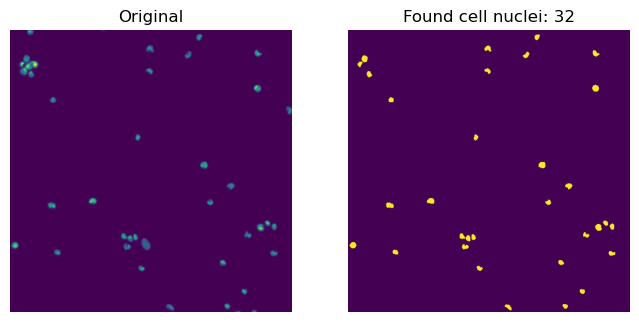

In [25]:
show_comparison(img_gray, i_filtered, f'Found cell nuclei: {counter_nuclei}')

## Exercise 15

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/2467297652.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gray, vmin=0, vmax=150)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/2467297652.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


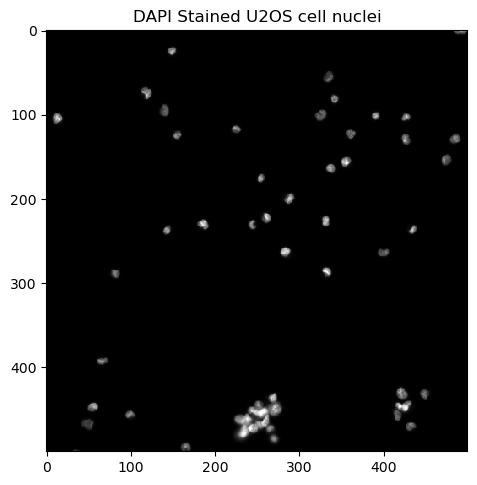

In [26]:
# slice to extract smaller image
img_small = img_org[200:700, 900:1400]
img_gray = img_as_ubyte(img_small) 
io.imshow(img_gray, vmin=0, vmax=150)
plt.title('DAPI Stained U2OS cell nuclei')
io.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


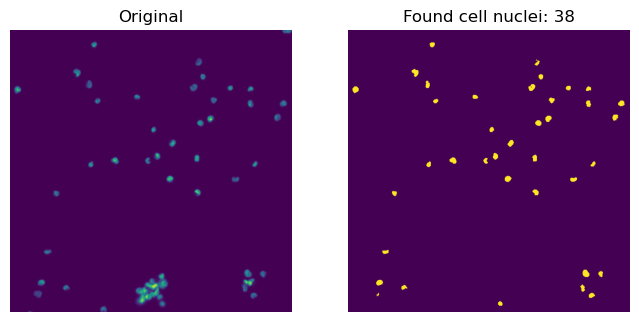

In [27]:
i_filtered, counter_nuclei = cell_counting(img_gray)
show_comparison(img_gray, i_filtered, f'Found cell nuclei: {counter_nuclei}')

## Exercise 16

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/515011101.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gray, vmin=0, vmax=150)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/515011101.py:8: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


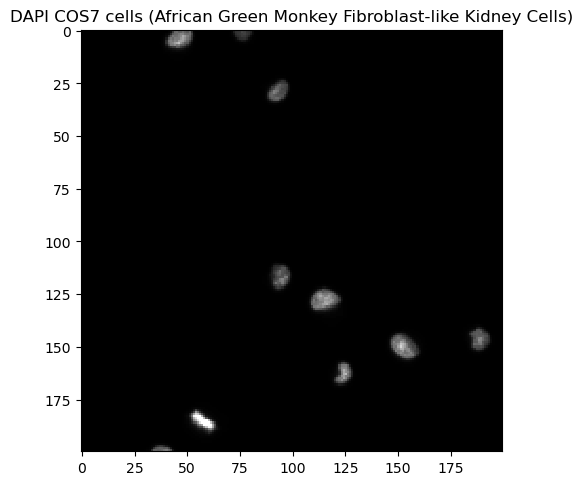

In [36]:
img_org = io.imread(in_dir + 'Sample G1 - COS7 cells DAPI channel.tiff')

# slice to extract smaller image
img_small = img_org[700:900, 900:1100]
img_gray = img_as_ubyte(img_small) 
io.imshow(img_gray, vmin=0, vmax=150)
plt.title('DAPI COS7 cells (African Green Monkey Fibroblast-like Kidney Cells)')
io.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


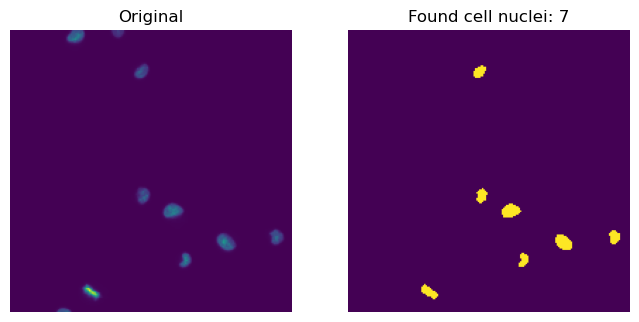

In [37]:
i_filtered, counter_nuclei = cell_counting(img_gray)
show_comparison(img_gray, i_filtered, f'Found cell nuclei: {counter_nuclei}')

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/2331351074.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gray, vmin=0, vmax=150)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/2331351074.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


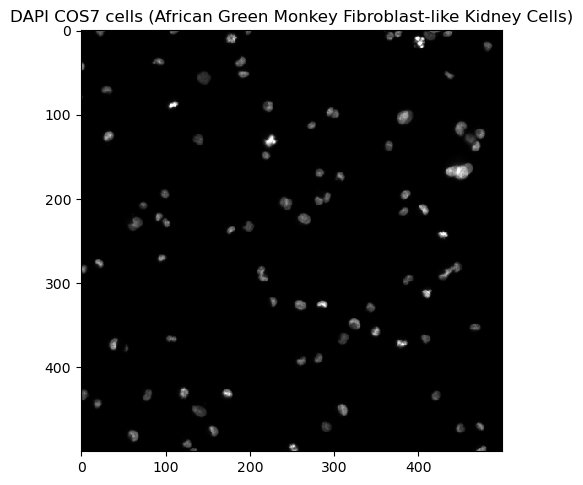

In [38]:
# slice to extract smaller image
img_small = img_org[100:600, 100:600]
img_gray = img_as_ubyte(img_small) 
io.imshow(img_gray, vmin=0, vmax=150)
plt.title('DAPI COS7 cells (African Green Monkey Fibroblast-like Kidney Cells)')
io.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/4028091458.py:17: RuntimeWarning: divide by zero encountered in divide
  circularities = (4 * np.pi * areas) / (perimeters**2)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


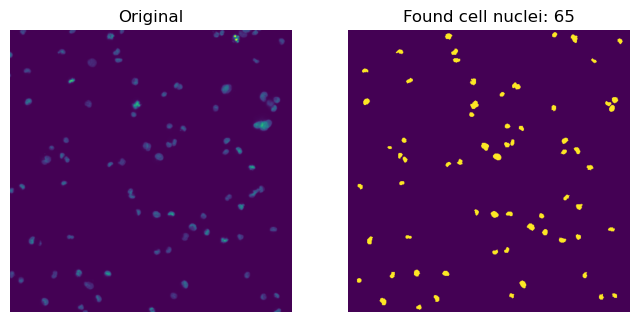

In [39]:
i_filtered, counter_nuclei = cell_counting(img_gray)
show_comparison(img_gray, i_filtered, f'Found cell nuclei: {counter_nuclei}')

## Exercise 17

In [42]:
def cell_counting_overlap(img_gray, min_area = 10, max_area = 150, min_circ = 0.7):

    # To binary
    thres = threshold_otsu(img_gray)
    img_bin = img_gray > thres

    # Remove border
    img_c_b = segmentation.clear_border(img_bin)

    # Handle overlap: opening before labeling
    footprint = morphology.disk(1)
    img_opened = morphology.binary_opening(img_c_b, footprint)

    # Label objects (BLOBs)
    label_img = measure.label(img_opened)

    # Extract features
    region_props = measure.regionprops(label_img)
    areas = np.array([prop.area for prop in region_props])
    perimeters = np.array([prop.perimeter for prop in region_props])
    circularities = (4 * np.pi * areas) / (perimeters**2)

    # Filter regions
    counter = 0
    label_img_filter = label_img.copy()
    for i in range(len(region_props)):
        # Find the areas that do not fit our criteria
        if (circularities[i] < min_circ) or (areas[i] > max_area) or (areas[i] < min_area):
            # set the pixels in the invalid areas to background
            for cords in region_props[i].coords:
                label_img_filter[cords[0], cords[1]] = 0
        else:
            counter += 1

    # Create binary image from the filtered label image
    i_filtered = label_img_filter > 0

    return i_filtered, counter

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/983487750.py:12: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  img_opened = morphology.binary_opening(img_c_b, footprint)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_39479/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


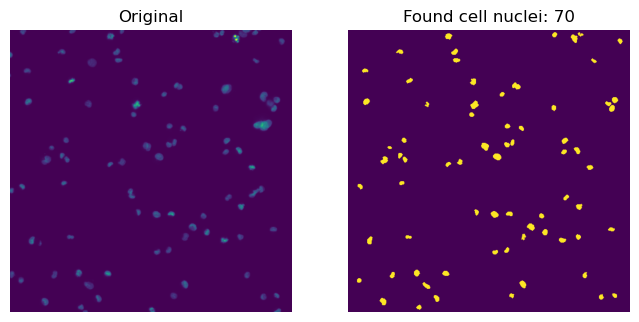

In [43]:
i_filtered, counter_nuclei = cell_counting_overlap(img_gray)
show_comparison(img_gray, i_filtered, f'Found cell nuclei: {counter_nuclei}')